<a href="https://colab.research.google.com/github/Akshar-RAO-7/APP/blob/main/INTERNSHIP_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# Adjust filenames/paths to match what you downloaded
sentiment = pd.read_csv("/fear_greed_index.csv")
trades = pd.read_csv("/historical_data.csv")

print(sentiment.shape, trades.shape)
sentiment.head()

(2644, 4) (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [13]:
#Clean the sentiment data
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment = sentiment[['date', 'classification']].drop_duplicates()

# Simplify to Fear vs Greed (optional — keep Extreme Fear/Greed if you want finer granularity)
sentiment['Sentiment'] = sentiment['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

In [15]:
#Clean the trader data based on provided code (corrected for column names)
# 'Timestamp' is usually a unix timestamp in ms — check and adjust
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms', errors='coerce')
if trades['Timestamp'].isna().mean() > 0.5:
    # fallback if it wasn't ms
    trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], errors='coerce')

trades['Date'] = trades['Timestamp'].dt.normalize()

# Make sure numeric cols are numeric
num_cols = ['Execution Price', 'Size Tokens', 'Closed PnL', 'leverage']
for c in num_cols:
    if c in trades.columns:
        trades[c] = pd.to_numeric(trades[c], errors='coerce')

# Display trades head after cleaning for verification
display(trades.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27


In [17]:
#Merge on date
df = trades.merge(sentiment[['date', 'Sentiment', 'classification']], left_on='Date', right_on='date', how='left')
print(df['Sentiment'].isna().sum(), "trades with no matching sentiment date")
df = df.dropna(subset=['Sentiment'])
df = df.drop(columns=['date']) # Drop the redundant 'date' column from sentiment after merge

26961 trades with no matching sentiment date


In [20]:
#Daily / account-level aggregation
daily = df.groupby(['Date', 'Sentiment']).agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    trade_count=('Closed PnL', 'count'),
    total_volume=('Size Tokens', 'sum'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean())
).reset_index()

daily.head()

,Date,Sentiment,total_pnl,avg_pnl,trade_count,total_volume,win_rate
0,2023-03-28,Greed,0.000000e+00,0.000000,3,2.513000e-01,0.000000
1,2023-11-14,Greed,1.555034e+02,0.148807,1045,2.681692e+06,0.274641
2,2024-03-09,Greed,1.769655e+05,25.418772,6962,3.393031e+08,0.490089
3,2024-07-03,Neutral,1.587424e+05,22.229713,7141,1.404851e+07,0.317182
4,2024-10-27,Greed,3.189461e+06,90.504272,35241,7.831963e+07,0.451605


In [22]:
#Compare performance by sentiment
summary = df.groupby('Sentiment').agg(
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean()),
    avg_size=('Size Tokens', 'mean'),
    trade_count=('Closed PnL', 'count')
)
print(summary)

             avg_pnl  median_pnl  win_rate     avg_size  trade_count
Sentiment                                                           
Fear       50.047622         0.0  0.415146  3071.523165       133871
Greed      77.838247         0.0  0.453492  9717.797033        43251
Neutral    22.229713         0.0  0.317182  1967.302964         7141


In [25]:
#Statistical significance check:
from scipy import stats

fear_pnl = df[df['Sentiment'] == 'Fear']['Closed PnL'].dropna()
greed_pnl = df[df['Sentiment'] == 'Greed']['Closed PnL'].dropna()

t_stat, p_val = stats.ttest_ind(fear_pnl, greed_pnl, equal_var=False)
print(f"t-stat: {t_stat:.3f}, p-value: {p_val:.4f}")

t-stat: -4.904, p-value: 0.0000


In [30]:
#Long/short bias by sentiment
if 'side' in df.columns:
    side_sentiment = df.groupby(['Sentiment', 'side']).agg(
        avg_pnl=('closedPnL', 'mean'),
        count=('closedPnL', 'count')
    ).reset_index()
    print(side_sentiment)

In [44]:
#Leverage risk-taking by sentiment
# Leverage risk-taking by sentiment
print(df.columns.tolist())  # check exact column names once

# Find the leverage column regardless of casing
lev_col = next((c for c in df.columns if c.lower() == 'leverage'), None)
sent_col = next((c for c in df.columns if c.lower() == 'sentiment'), None)

if lev_col and sent_col:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x=sent_col, y=lev_col)
    plt.title("Leverage Distribution by Market Sentiment")
    plt.show()
else:
    print(f"Missing column — leverage found: {lev_col}, sentiment found: {sent_col}")

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date', 'Sentiment', 'classification']
Missing column — leverage found: None, sentiment found: Sentiment


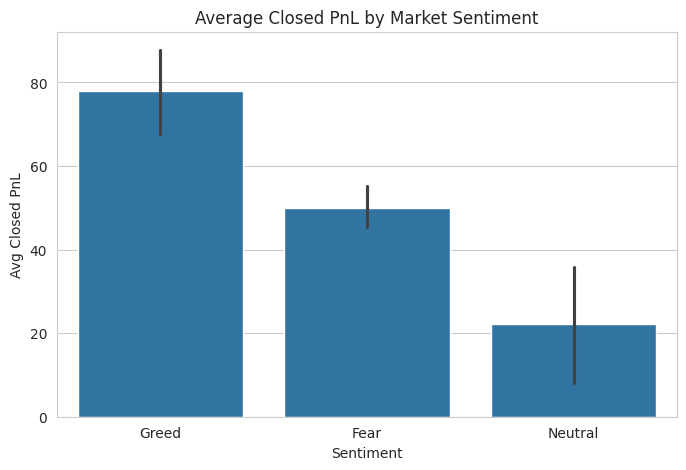

In [37]:
#PnL by sentiment — visualized
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Sentiment', y='Closed PnL', estimator=np.mean, errorbar='ci')
plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Avg Closed PnL")
plt.show()

<Figure size 1000x500 with 0 Axes>

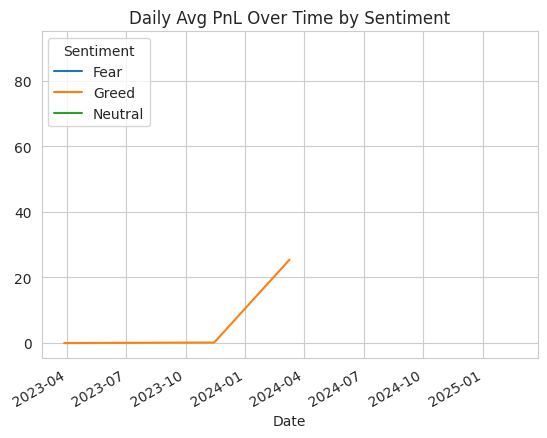

In [38]:
plt.figure(figsize=(10,5))
daily_pivot = daily.pivot_table(index='Date', columns='Sentiment', values='avg_pnl')
daily_pivot.plot()
plt.title("Daily Avg PnL Over Time by Sentiment")
plt.show()

In [40]:
#Account-level behavior (best/worst traders)
account_perf = df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean()),
    trade_count=('Closed PnL', 'count')
).sort_values('total_pnl', ascending=False)

top10 = account_perf.head(10)
bottom10 = account_perf.tail(10)

In [42]:
#Lag effect (yesterday's sentiment → today's performance)
sentiment_sorted = sentiment.sort_values('date').copy()
sentiment_sorted['Sentiment_lag1'] = sentiment_sorted['Sentiment'].shift(1)
sentiment_sorted['Date_lag'] = sentiment_sorted['date']

df_lag = df.merge(
    sentiment_sorted[['date', 'Sentiment_lag1']],
    left_on='Date', right_on='date', how='left'
)

lag_summary = df_lag.groupby('Sentiment_lag1')['Closed PnL'].mean()
print(lag_summary)

Sentiment_lag1
Greed      77.838247
Neutral    48.638893
Name: Closed PnL, dtype: float64
